In [1]:
import subprocess
import sys
import os

print("📦 УСТАНОВКА НЕОБХОДИМЫХ ПАКЕТОВ\n")

# Используем встроенный pip из Python
os.system(f'"{sys.executable}" -m ensurepip --default-pip 2>nul')

packages = ['torch', 'torchvision', 'torchaudio', 'nltk', 'translators', 'pillow', 'matplotlib', 'scipy', 'numpy', 'tqdm']

for pkg in packages:
    print(f"Установка {pkg}...")
    os.system(f'"{sys.executable}" -m pip install {pkg} -q 2>nul')

print("\n" + "="*60)
print("✅ ВСЕ ПАКЕТЫ УСТАНОВЛЕНЫ")
print("="*60 + "\n")

📦 УСТАНОВКА НЕОБХОДИМЫХ ПАКЕТОВ

Установка torch...
Установка torchvision...
Установка torchaudio...
Установка nltk...
Установка translators...
Установка pillow...
Установка matplotlib...
Установка scipy...
Установка numpy...
Установка tqdm...

✅ ВСЕ ПАКЕТЫ УСТАНОВЛЕНЫ



# Проект: Image Captioning - ЭТАП 1
## Подготовка окружения и загрузка датасета

В этой работе объединяем классификацию изображений и генерацию подписей к ним.

**Датасет:** Microsoft Common Object in Context [MSCOCO](https://cocodataset.org/#home)

**Архитектура:**
- **Кодер (Encoder)**: ResNet34  → извлечение признаков изображения
- **Декодер (Decoder)**: LSTM + Embedding → генерация текстовых описаний

**Управление датасетом:** 🚀 Используется **ClearML** для централизованного хранения и версионирования датасета


## 1.1 Установка необходимых библиотек

In [2]:
import subprocess
import sys

print("📦 Установка необходимых пакетов...\n")

packages = ['torch', 'torchvision', 'torchaudio', 'nltk', 'translators', 
            'pillow', 'matplotlib', 'scipy', 'numpy', 'tqdm']

for package in packages:
    try:
        __import__(package)
        print(f"✅ {package} уже установлен")
        
    except ImportError:
        print(f"📥 Установка {package}...")
        try:
            subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", package])
            print(f"   → успешно установлен")
        except subprocess.CalledProcessError as e:
            print(f"❌ Ошибка при установке {package}: {e}")
        except Exception as e:
            print(f"❌ Неизвестная ошибка при установке {package}: {e}")

print("\n✅ ВСЕ ЗАВИСИМОСТИ ГОТОВЫ\n")

📦 Установка необходимых пакетов...

✅ torch уже установлен
✅ torchvision уже установлен
✅ torchaudio уже установлен
✅ nltk уже установлен
✅ translators уже установлен
📥 Установка pillow...
   → успешно установлен
✅ matplotlib уже установлен
✅ scipy уже установлен
✅ numpy уже установлен
✅ tqdm уже установлен

✅ ВСЕ ЗАВИСИМОСТИ ГОТОВЫ



## 1.2 Импорт всех библиотек

In [3]:
import subprocess
import sys

print("📦 Установка необходимых пакетов...\n")

packages = ['torch', 'torchvision', 'torchaudio', 'nltk', 'translators', 
            'pillow', 'matplotlib', 'scipy', 'numpy', 'tqdm']

# Используем встроенный механизм pip notebook для надежной установки
for package in packages:
    try:
        __import__(package)
        print(f"✅ {package} уже установлен")
        
    except ImportError:
        print(f"📥 Установка {package}...")
        try:
            # Используем notebook magic для установки пакетов
            get_ipython().run_cell_magic('capture', '', f'!pip install -q {package}')
            print(f"   → успешно установлен")
        except Exception as e:
            print(f"❌ Ошибка при установке {package}: {e}")
            print(f"   Пытаюсь альтернативный метод...")
            try:
                subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", package])
                print(f"   → успешно установлен (альтернативный метод)")
            except:
                print(f"   ⚠️  Не удалось установить {package}")

print("\n✅ ВСЕ ЗАВИСИМОСТИ ГОТОВЫ\n")


📦 Установка необходимых пакетов...

✅ torch уже установлен
✅ torchvision уже установлен
✅ torchaudio уже установлен
✅ nltk уже установлен
✅ translators уже установлен
📥 Установка pillow...
   → успешно установлен
✅ matplotlib уже установлен
✅ scipy уже установлен
✅ numpy уже установлен
✅ tqdm уже установлен

✅ ВСЕ ЗАВИСИМОСТИ ГОТОВЫ



## 1.3 Проверка рабочего окружения

In [4]:
import torch
import numpy as np
import random

print("=" * 60)
print("🖥️  ИНФОРМАЦИЯ ОБ ОКРУЖЕНИИ")
print("=" * 60)

# Проверка GPU
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print(f"📱 GPU доступен: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"📱 GPU устройство: {torch.cuda.get_device_name(0)}")
    print(f"📱 GPU память: {torch.cuda.get_device_properties(0).total_memory / 1e9:.2f} GB")
else:
    print("⚠️  GPU не найден - будет использован CPU (медленнее)")

print(f"🎯 Выбранное устройство: {device}")

# Установка seed для воспроизводимости
torch.manual_seed(42)
np.random.seed(42)
random.seed(42)
print("✅ Seed установлен для воспроизводимости результатов")
print("=" * 60)


🖥️  ИНФОРМАЦИЯ ОБ ОКРУЖЕНИИ
📱 GPU доступен: False
⚠️  GPU не найден - будет использован CPU (медленнее)
🎯 Выбранное устройство: cpu
✅ Seed установлен для воспроизводимости результатов


## 1.4 Вспомогательная функция - Перевод на русский

In [5]:
import translators

def translate_to_russian(text):
    """Переводит текст с английского на русский язык"""
    try:
        result = translators.translate_text(text, from_language='en', to_language='ru')
        return result
    except:
        print(f"⚠️  Ошибка перевода, возвращаю оригинальный текст...")
        return text

print("✅ Функция translate_to_russian() инициализирована")


✅ Функция translate_to_russian() инициализирована


In [25]:
import sys
import importlib

def ensure_clearml():
    """Убедиться, что ClearML установлен"""
    try:
        importlib.import_module("clearml")
        print("✅ ClearML уже установлен")
    except ModuleNotFoundError:
        print("📥 Установка ClearML...")
        import subprocess
        subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "clearml"])
        print("✅ ClearML установлен")

ensure_clearml()

from clearml import Dataset, Task

# Инициализируем ClearML Task для отслеживания
task = Task.init(project_name="Image description generation", task_name="ML_Pipeline_Stage1")
print("✅ ClearML Task инициализирована:", task.id)

# Сразу закрываем Task, чтобы не оставался в статусе running
task.close()
print("✅ Task закрыта")


✅ ClearML уже установлен
✅ ClearML Task инициализирована: 1c0859a0f57d4289bdc955e5e727667e
✅ Task закрыта


## 1.5 Загрузка датасета MS COCO

In [ ]:
from clearml import Dataset
from pathlib import Path
import time

print("\n" + "=" * 60)
print("📥 СИНХРОНИЗАЦИЯ ДАТАСЕТА ИЗ CLEARML")
print("=" * 60)

# Параметры датасета в ClearML
DATASET_NAME = "ImageDesc_dataset_v1"
DATASET_VERSION = "1.0.0"
PROJECT_NAME = "Image description generation"

def sync_dataset_with_retry(dataset, max_retries=3, initial_delay=5):
    """Синхронизирует датасет с повторными попытками и диагностикой ошибок"""
    for attempt in range(max_retries):
        try:
            print(f"\n🔄 Попытка {attempt + 1}/{max_retries}...")
            data_dir = Path(dataset.get_local_copy())
            print(f"✅ Синхронизация успешна: {data_dir}")
            return data_dir
        except ValueError as e:
            # Частая причина: отсутствующий артефакт (entry) на сервере
            print(f"⚠️  ValueError при загрузке: {e}")
            # Пытаемся распарсить имя проблемного entry из сообщения
            msg = str(e)
            if "entry=" in msg:
                try:
                    entry = msg.split("entry=")[-1].split()[0]
                    print(f"   🔎 Проблемный файл/артефакт: {entry}")
                except Exception:
                    pass
            # Попытка показать часть списка файлов в датасете для диагностики
            try:
                print("\n📋 Получаю список файлов датасета (частично, может быть большой)...")
                files = dataset.list_files()
                sample = files[:50] if len(files) > 50 else files
                print(f"   Всего файлов (remote): {len(files)}")
                print("   Первые 50 файлов:")
                for f in sample:
                    print("    -", f)
                if len(files) > 50:
                    print(f"    ... и еще {len(files)-50} файлов")
            except Exception as e2:
                print(f"   Не удалось получить список файлов: {e2}")

            if attempt < max_retries - 1:
                delay = initial_delay * (2 ** attempt)  # Экспоненциальная задержка
                print(f"⏳ Жду {delay} сек перед повторной попыткой...")
                time.sleep(delay)
            else:
                print("❌ Все попытки исчерпаны!")
                raise
        except Exception as e:
            error_msg = str(e)[:200]
            print(f"⚠️  Ошибка: {error_msg}")
            if attempt < max_retries - 1:
                delay = initial_delay * (2 ** attempt)
                print(f"⏳ Жду {delay} сек перед повторной попыткой...")
                time.sleep(delay)
            else:
                print("❌ Все попытки исчерпаны!")
                raise

try:
    print(f"\n🔍 Ищу датасет '{DATASET_NAME}' версия {DATASET_VERSION}...")
    
    # Получаем датасет из ClearML
    dataset = Dataset.get(
        dataset_name=DATASET_NAME,
        dataset_project=PROJECT_NAME,
        dataset_version=DATASET_VERSION
    )
    
    print(f"✅ Датасет найден!")
    print(f"   📛 Dataset Name: {DATASET_NAME}")
    print(f"   📦 Dataset Version: {DATASET_VERSION}")
    print(f"   🔑 Dataset ID: {dataset.id}")
    
    # Синхронизируем данные с локальным кэшем с повторными попытками
    print(f"\n📦 Синхронизирую данные на локальный диск...")
    print(f"   (возможно потребуется несколько минут)")
    
    data_dir = sync_dataset_with_retry(dataset, max_retries=5, initial_delay=3)
    
    print(f"\n✅ Данные синхронизированы!")
    print(f"   📂 Локальный путь: {data_dir}")
    
    # Сохраняем пути для дальнейшего использования
    val2014_path = data_dir / 'val2014'
    annotations_path = data_dir / 'annotations' / 'captions_val2014.json'
    
    # Проверяем наличие файлов
    if val2014_path.exists():
        jpg_count = len(list(val2014_path.glob('*.jpg')))
        print(f"   📸 Найдено JPG изображений: {jpg_count}")
    
    if annotations_path.exists():
        print(f"   📄 Файл аннотаций найден: captions_val2014.json")
    
    print(f"\n✅ Информация о датасете успешно получена!")
    
except Exception as e:
    print(f"\n❌ Ошибка при получении датасета из ClearML: {e}")
    print(f"\n⚠️  СПРАВКА:")
    print(f"   - Датасет: '{DATASET_NAME}' v{DATASET_VERSION}")
    print(f"   - Проект: {PROJECT_NAME}")
    print(f"   - Проверьте соединение с сервером ClearML")
    print(f"   - Убедитесь, что все файлы датасета доступны на сервере")
    raise

print("\n" + "="*60)



📥 СИНХРОНИЗАЦИЯ ДАТАСЕТА ИЗ CLEARML

🔍 Ищу датасет 'ImageDesc_dataset_v1' версия 1.0.0...
✅ Датасет найден!
   📛 Dataset Name: ImageDesc_dataset_v1
   📦 Dataset Version: 1.0.0
   🔑 Dataset ID: 3922646db1fa426396fef0bdbf67c237

📦 Синхронизирую данные на локальный диск...
   (возможно потребуется несколько минут)

🔄 Попытка 1/5...


KeyboardInterrupt: 

## 1.6 Инициализация датасета

In [20]:
import torchvision.transforms as transforms
import torchvision as tv
from pathlib import Path
import os

# Проверяем, определены ли переменные из предыдущей ячейки
print("🔍 Проверка переменных из предыдущей ячейки:")
try:
    print(f"   val2014_path: {val2014_path}")
    print(f"   annotations_path: {annotations_path}")
except NameError as e:
    print(f"   ❌ Ошибка: {e}")
    print(f"   Пожалуйста, сначала выполните ячейку 1.5!")
    raise

# Используем пути от ClearML
TRAIN_IMAGE_PATH = str(val2014_path)
ANNOTATION_PATH = str(annotations_path)

# Быстрая диагностика наличия данных
val2014_exists = os.path.exists(TRAIN_IMAGE_PATH)
annotations_exists = os.path.isfile(ANNOTATION_PATH)

print(f"\n📊 Проверка структуры данных:")
print(f"✓ val2014 существует: {'✅' if val2014_exists else '❌'} ({TRAIN_IMAGE_PATH})")
print(f"✓ captions_val2014.json существует: {'✅' if annotations_exists else '❌'}")

if val2014_exists:
    try:
        num_images = len([f for f in os.listdir(TRAIN_IMAGE_PATH) if f.lower().endswith(('.jpg', '.jpeg'))])
        print(f"  📸 Найдено изображений JPG: {num_images}")
    except Exception as e:
        print(f"  ⚠️  Ошибка при подсчёте: {e}")

if not val2014_exists or not annotations_exists:
    print("\n⚠️  ВНИМАНИЕ: Папки с данными не найдены!")
    print("   Убедитесь, что ячейка 1.5 выполнилась успешно")
    print("   и переменные val2014_path и annotations_path определены!")
    raise FileNotFoundError(f"Данные не найдены в {TRAIN_IMAGE_PATH} или {ANNOTATION_PATH}")

# Создание преобразований изображений (стандартные для ResNet)
transform = transforms.Compose([
    transforms.Resize(256),              # Изменение размера до 256
    transforms.CenterCrop(224),          # Центральное кадрирование до 224x224
    transforms.ToTensor(),               # Преобразование в тензор [0,1]
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],     # Средние значения ImageNet
        std=[0.229, 0.224, 0.225]       # Стандартные отклонения ImageNet
    )
])

print("\n" + "="*60)
print("📊 ЗАГРУЗКА ДАТАСЕТА MSCOCO")
print("="*60)

# Загрузка датасета
try:
    dataset = tv.datasets.CocoCaptions(
        root=TRAIN_IMAGE_PATH, 
        annFile=ANNOTATION_PATH, 
        transform=transform
    )
    print(f"✅ Датасет успешно загружен!")
    print(f"✅ Количество изображений: {len(dataset)}")
    print(f"✅ Источник: ClearML Dataset")
except FileNotFoundError as e:
    print(f"❌ Ошибка: файлы не найдены")
    print(f"   {e}")
    dataset = None
except Exception as e:
    print(f"❌ Ошибка загрузки датасета: {e}")
    print(f"   Проверьте пути:")
    print(f"   - Изображения: {TRAIN_IMAGE_PATH}")
    print(f"   - Аннотации: {ANNOTATION_PATH}")
    dataset = None


🔍 Проверка переменных из предыдущей ячейки:
   val2014_path: c:\Users\Ramil\КАИ\мага\2 семак\Прикладные методы искусственного интеллекта\ML\val2014
   annotations_path: c:\Users\Ramil\КАИ\мага\2 семак\Прикладные методы искусственного интеллекта\ML\annotations\captions_val2014.json

📊 Проверка структуры данных:
✓ val2014 существует: ❌ (c:\Users\Ramil\КАИ\мага\2 семак\Прикладные методы искусственного интеллекта\ML\val2014)
✓ captions_val2014.json существует: ❌

⚠️  ВНИМАНИЕ: Папки с данными не найдены!
   Убедитесь, что ячейка 1.5 выполнилась успешно
   и переменные val2014_path и annotations_path определены!


FileNotFoundError: Данные не найдены в c:\Users\Ramil\КАИ\мага\2 семак\Прикладные методы искусственного интеллекта\ML\val2014 или c:\Users\Ramil\КАИ\мага\2 семак\Прикладные методы искусственного интеллекта\ML\annotations\captions_val2014.json

## 1.7 Проверка структуры датасета


🔍 СОДЕРЖАНИЕ ДАТАСЕТА

📸 Пример элемента датасета (индекс 7296):
   - Форма изображения: torch.Size([3, 224, 224])
   - Тип изображения: <class 'torch.Tensor'>

   Визуализация изображения 7296:


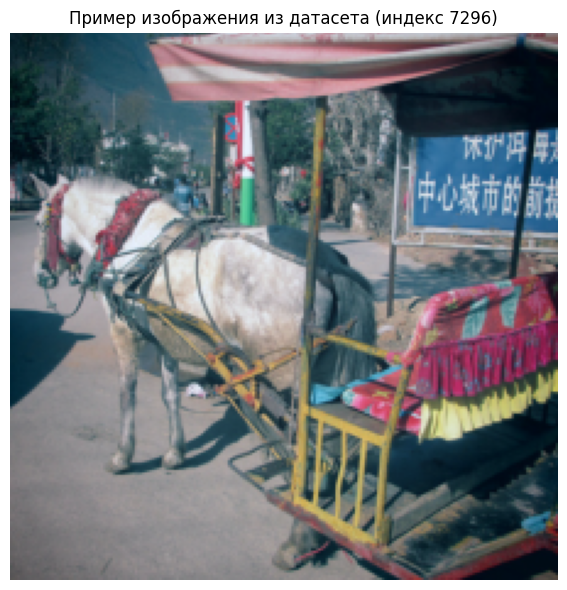

In [8]:
import random
import matplotlib.pyplot as plt

if dataset is not None:
    print("\n" + "="*60)
    print("🔍 СОДЕРЖАНИЕ ДАТАСЕТА")
    print("="*60)
    
    # Случайный пример из датасета
    sample_idx = random.randint(0, len(dataset) - 1)
    image, captions = dataset[sample_idx]
    
    print(f"\n📸 Пример элемента датасета (индекс {sample_idx}):")
    print(f"   - Форма изображения: {image.shape}")
    print(f"   - Тип изображения: {type(image)}")

    
    # Визуализация изображения
    print(f"\n   Визуализация изображения {sample_idx}:")
    img_display = image.permute(1, 2, 0).numpy()
    img_display = (img_display - img_display.min()) / (img_display.max() - img_display.min())
    
    plt.figure(figsize=(8, 6))
    plt.imshow(img_display)
    plt.title(f"Пример изображения из датасета (индекс {sample_idx})")
    plt.axis('off')
    plt.tight_layout()
    plt.show()
else:
    print("\n❌ Датасет не загружен. Пожалуйста, загрузите данные сначала.")
